
# MVP — Análise de Dados e Boas Práticas

**Tema:** Desigualdades no desempenho em matemática no Brasil: uma análise da rede de ensino, localização, diferenças regionais e a hipótese da formação docente, com base nos dados do SAEB.

**Aluno:** Marcos Vilarindo Paeslandim Rodrigues

**Matrícula:** 4052025000312

**Dataset:** planilhas agregadas do SAEB por UF (2017, 2019 e 2021)

---

## Observação importante
Este notebook foi estruturado como **relatório técnico**, combinando:
- definição do problema;
- análise exploratória de dados;
- visualização da informação;
- pré-processamento de dados.

O eixo **formação docente** aparece aqui como **hipótese interpretativa** e não como variável observada diretamente, pois os três arquivos utilizados não trazem uma coluna explícita de adequação da formação docente. Assim, os resultados quantitativos medem diretamente **rede de ensino**, **localização** e **região**, enquanto a formação docente é discutida como um fator potencialmente associado aos padrões encontrados.



## 1. Introdução

As desigualdades educacionais brasileiras se manifestam de forma particularmente intensa no ensino de matemática. Em avaliações em larga escala, observa-se que o desempenho dos estudantes varia de acordo com fatores estruturais como rede de ensino, localização geográfica e região do país. Essas diferenças são relevantes porque a matemática ocupa papel central no desenvolvimento do raciocínio lógico, da resolução de problemas e da progressão acadêmica dos alunos.

Ao investigar esse cenário, torna-se importante compreender se estudantes de escolas públicas e privadas apresentam padrões distintos de proficiência, se há diferenças sistemáticas entre contextos urbanos e rurais e se as disparidades regionais reforçam ou ampliam essas desigualdades. Além disso, embora não seja mensurada diretamente neste conjunto de dados, a adequação da formação docente aparece como uma hipótese explicativa plausível para parte das diferenças observadas, sobretudo em contextos historicamente mais vulneráveis.

Dessa forma, este estudo utiliza dados agregados do SAEB por unidade federativa para analisar o desempenho em matemática e produzir evidências descritivas sobre desigualdades educacionais no Brasil.



## 2. Descrição do problema

Este trabalho busca responder à seguinte questão: **como o desempenho em matemática varia no Brasil quando se consideram a rede de ensino (pública e privada), a localização (urbana e rural) e as diferenças regionais?**

A intenção é verificar se essas dimensões estão associadas a padrões consistentes de desigualdade. Em outras palavras, pretende-se observar se:
- escolas privadas apresentam médias superiores às escolas públicas;
- contextos urbanos apresentam desempenho superior aos contextos rurais;
- determinadas regiões concentram melhores ou piores resultados;
- as diferenças entre essas categorias permanecem ou se intensificam ao longo dos anos disponíveis.

Por fim, o estudo considera como hipótese interpretativa que parte dessas desigualdades pode também estar relacionada a diferenças na adequação da formação docente, ainda que isso não possa ser testado diretamente com os arquivos utilizados.



## 3. Hipóteses do problema

As hipóteses que orientam este MVP são as seguintes:

1. Estudantes de escolas privadas apresentam maior proficiência em matemática do que estudantes de escolas públicas.
2. Estudantes de áreas urbanas apresentam melhor desempenho em matemática do que estudantes de áreas rurais.
3. As desigualdades regionais são significativas, com vantagem para regiões historicamente mais favorecidas em termos socioeconômicos.
4. As diferenças entre público e privado e entre urbano e rural permanecem visíveis nos anos analisados.
5. A adequação da formação docente pode atuar como fator associado às diferenças de desempenho, especialmente em regiões e redes mais vulneráveis.

**Tipo de problema:** trata-se de um problema de **análise exploratória de dados**, com abordagem predominantemente **não supervisionada**, pois o objetivo não é prever valores, mas identificar padrões, diferenças e possíveis associações entre variáveis.



## 4. Seleção dos dados e atributos

Foram utilizados três arquivos agregados do SAEB por unidade federativa:

- `TS_UF_2017_TOTAL.csv`
- `TS_UF_2019_TOTAL.csv`
- `TS_UF_2021_TOTAL.csv`

### Atributos principais utilizados
- `CO_UF`: código da unidade federativa;
- `NO_UF`: nome da unidade federativa;
- `DEPENDENCIA_ADM`: rede de ensino;
- `LOCALIZACAO`: localização da escola;
- `MEDIA_5_MT`: proficiência média em matemática no 5º ano;
- `MEDIA_9_MT`: proficiência média em matemática no 9º ano;
- `MEDIA_12_MT`: proficiência média em matemática no Ensino Médio.

### Restrição metodológica
Como os arquivos não contêm uma variável direta sobre adequação da formação docente, essa dimensão será discutida apenas como **hipótese explicativa** e **limitação do estudo**, e não como medida empírica direta.


## 5. Importação das Bibliotecas Necessárias e Carregamento de Dados

Esta seção consolida todas as importações de bibliotecas necessárias para a análise, visualização e pre-processamento dos dados, bem como o carregamento inicial do dataset.

In [ ]:
# IMPORTAÇÃO DAS BIBLIOTECAS NECESSÁRIAS

import warnings
warnings.filterwarnings("ignore")

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler, MinMaxScaler

plt.rcParams["figure.figsize"] = (10, 6)
sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", None)


In [ ]:
# CARREGAMENTO DOS DADOS (SAEB)
url_2017 = "https://raw.githubusercontent.com/marcosvilarindo-professor/mvp-analise-de-dados-e-boas-praticas/main/Dados/TS_UF_2017_TOTAL.csv"
url_2019 = "https://raw.githubusercontent.com/marcosvilarindo-professor/mvp-analise-de-dados-e-boas-praticas/main/Dados/TS_UF_2019_TOTAL.csv"
url_2021 = "https://raw.githubusercontent.com/marcosvilarindo-professor/mvp-analise-de-dados-e-boas-praticas/main/Dados/TS_UF_2021_TOTAL.csv"

df_2017 = pd.read_csv(url_2017, sep=';', encoding='latin1')
df_2019 = pd.read_csv(url_2019, sep=';', encoding='latin1')
df_2021 = pd.read_csv(url_2021, sep=';', encoding='latin1')

# visualizar dados
df_2017.head()
df_2019.head()
df_2021.head()

# AJUSTE DE TIPOS (IMPORTANTE)
cols = ["MEDIA_5_MT", "MEDIA_9_MT", "MEDIA_12_MT"]

for col in cols:
    df_2017[col] = df_2017[col].astype(str).str.replace(",", ".").astype(float)
    df_2019[col] = df_2019[col].astype(str).str.replace(",", ".").astype(float)
    df_2021[col] = df_2021[col].astype(str).str.replace(",", ".").astype(float)


## 6. Carga dos dados

Carga dos dados...na versão final para entrega no GitHub os caminhos locais foram substituídos pelos links `raw` do repositório.
Aqui, o notebook está pronto para funcionar com os arquivos `.csv` no mesmo ambiente.


In [ ]:

ARQUIVOS = {
    2017: "https://raw.githubusercontent.com/marcosvilarindo-professor/mvp-analise-de-dados-e-boas-praticas/main/Dados/TS_UF_2017_TOTAL.csv",
    2019: "https://raw.githubusercontent.com/marcosvilarindo-professor/mvp-analise-de-dados-e-boas-praticas/main/Dados/TS_UF_2019_TOTAL.csv",
    2021: "https://raw.githubusercontent.com/marcosvilarindo-professor/mvp-analise-de-dados-e-boas-praticas/main/Dados/TS_UF_2021_TOTAL.csv"
}



## 7. Pré-processamento inicial e padronização

As planilhas de 2017, 2019 e 2021 não possuem exatamente a mesma estrutura textual para a coluna de dependência administrativa.  
Por isso, a primeira etapa de pré-processamento consiste em:

1. selecionar apenas as colunas relevantes;
2. harmonizar os nomes das categorias de rede de ensino;
3. criar a variável `REGIAO` a partir da UF;
4. agregar registros quando necessário, evitando duplicidades introduzidas pela planilha de 2017.


In [ ]:

REGIAO_MAP = {
    "Rondônia": "Norte", "Acre": "Norte", "Amazonas": "Norte", "Roraima": "Norte",
    "Pará": "Norte", "Amapá": "Norte", "Tocantins": "Norte",
    "Maranhão": "Nordeste", "Piauí": "Nordeste", "Ceará": "Nordeste",
    "Rio Grande do Norte": "Nordeste", "Paraíba": "Nordeste", "Pernambuco": "Nordeste",
    "Alagoas": "Nordeste", "Sergipe": "Nordeste", "Bahia": "Nordeste",
    "Minas Gerais": "Sudeste", "Espírito Santo": "Sudeste",
    "Rio de Janeiro": "Sudeste", "São Paulo": "Sudeste",
    "Paraná": "Sul", "Santa Catarina": "Sul", "Rio Grande do Sul": "Sul",
    "Mato Grosso": "Centro-Oeste", "Mato Grosso do Sul": "Centro-Oeste",
    "Goiás": "Centro-Oeste", "Distrito Federal": "Centro-Oeste"
}

def carregar_e_padronizar(caminho_arquivo, ano):
    df = pd.read_csv(caminho_arquivo, sep=';', encoding='latin1')

    # limpar nomes das colunas
    df.columns = [col.strip() for col in df.columns]

    colunas_base = [c for c in ["CO_UF", "NO_UF", "DEPENDENCIA_ADM", "LOCALIZACAO"] if c in df.columns]
    colunas_metricas = [c for c in ["MEDIA_5_MT", "MEDIA_9_MT", "MEDIA_12_MT"] if c in df.columns]
    df = df[colunas_base + colunas_metricas].copy()

    for col in colunas_metricas:
        df[col] = pd.to_numeric(
            df[col].astype(str).str.replace(",", ".", regex=False),
            errors="coerce"
        )

    dependencia = df["DEPENDENCIA_ADM"].astype(str).str.strip()

    if ano == 2017:
        dependencia = dependencia.replace({
            "Total - Federal, Estadual e Municipal": "Pública",
            "Total - Estadual e Municipal": "Pública",
            "Federal": "Pública",
            "Estadual": "Pública",
            "Municipal": "Pública",
            "Privada": "Privada",
            "Total - Federal, Estadual, Municipal e Privada": "Total",
        })
    else:
        dependencia = dependencia.replace({
            "TOTAL": "Total",
            "Total": "Total",
            "Pública": "Pública",
            "Privada": "Privada",
        })

    df["DEPENDENCIA_ADM"] = dependencia
    df["REGIAO"] = df["NO_UF"].map(REGIAO_MAP)
    df["ANO"] = ano

    colunas_groupby = [c for c in ["ANO", "CO_UF", "NO_UF", "REGIAO", "DEPENDENCIA_ADM", "LOCALIZACAO"] if c in df.columns]

    df = (
        df.groupby(colunas_groupby, as_index=False)[colunas_metricas]
        .mean()
    )

    return df

df_2017 = carregar_e_padronizar(ARQUIVOS[2017], 2017)
df_2019 = carregar_e_padronizar(ARQUIVOS[2019], 2019)
df_2021 = carregar_e_padronizar(ARQUIVOS[2021], 2021)

df_all = pd.concat([df_2017, df_2019, df_2021], ignore_index=True)

print("Dimensões após padronização:")
print("2017:", df_2017.shape)
print("2019:", df_2019.shape)
print("2021:", df_2021.shape)
print("Base consolidada:", df_all.shape)

# padronizar a rede em dois grupos: Pública e Privada
mapa_rede = {
    "Federal": "Pública",
    "Estadual": "Pública",
    "Municipal": "Pública",
    "Pública": "Pública",
    "PÃºblica": "Pública",
    "Privada": "Privada"
}

df_all["REDE_GRUPO"] = df_all["DEPENDENCIA_ADM"].map(mapa_rede)

print("Valores únicos de REDE_GRUPO:")
print(df_all["REDE_GRUPO"].unique())

df_redes = df_all[df_all["REDE_GRUPO"].isin(["Pública", "Privada"])].copy()

print("Valores no df_redes:")
print(df_redes["REDE_GRUPO"].unique())


Dimensões após padronização:
2017: (243, 9)
2019: (143, 8)
2021: (143, 8)
Base consolidada: (529, 9)
Valores únicos de REDE_GRUPO:
['Privada' 'Pública' nan]
Valores no df_redes:
['Privada' 'Pública']



**Interpretação:**  
A etapa inicial de pré-processamento foi necessária para tornar comparáveis os arquivos de anos distintos. A principal transformação consistiu em harmonizar a dependência administrativa e agregar registros equivalentes. Isso é importante para garantir consistência analítica e evitar interpretações enviesadas por diferenças de estrutura entre planilhas.



## 8. Inspeção inicial dos dados

Nesta etapa, foi verificado quantidade de instâncias, tipos de dados, primeiras linhas e presença de valores faltantes.


In [ ]:

df_all.head()


,ANO,CO_UF,NO_UF,REGIAO,DEPENDENCIA_ADM,LOCALIZACAO,MEDIA_5_MT,MEDIA_9_MT,MEDIA_12_MT,REDE_GRUPO
0,2017,11.0,Rondônia,Norte,Privada,Rural,151.433333,178.640000,188.940000,Privada
1,2017,11.0,Rondônia,Norte,Privada,Total,252.763333,302.640000,317.580000,Privada
2,2017,11.0,Rondônia,Norte,Privada,Urbana,252.930000,304.620000,319.136667,Privada
3,2017,11.0,Rondônia,Norte,Pública,Rural,169.460000,202.354667,153.720000,Pública
4,2017,11.0,Rondônia,Norte,Pública,Total,175.648000,204.155333,160.744000,Pública


In [ ]:

df_all.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 529 entries, 0 to 528
Data columns (total 10 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   ANO              529 non-null    int64  
 1   CO_UF            243 non-null    float64
 2   NO_UF            529 non-null    object 
 3   REGIAO           529 non-null    object 
 4   DEPENDENCIA_ADM  529 non-null    object 
 5   LOCALIZACAO      529 non-null    object 
 6   MEDIA_5_MT       526 non-null    float64
 7   MEDIA_9_MT       519 non-null    float64
 8   MEDIA_12_MT      515 non-null    float64
 9   REDE_GRUPO       352 non-null    object 
dtypes: float64(4), int64(1), object(5)
memory usage: 41.5+ KB


In [ ]:

df_all.isnull().sum()


,0
ANO,0
CO_UF,286
NO_UF,0
REGIAO,0
DEPENDENCIA_ADM,0
LOCALIZACAO,0
MEDIA_5_MT,3
MEDIA_9_MT,10
MEDIA_12_MT,14
REDE_GRUPO,177



**Interpretação:**  
A base consolidada apresenta estrutura predominantemente numérica nas variáveis de proficiência e categórica nas variáveis de classificação. Observa-se ainda a existência de alguns valores ausentes, especialmente em combinações mais específicas, o que reforça a necessidade de tratamento antes da análise comparativa mais fina.



## 9. Criação de recortes analíticos

Para evitar dupla contagem, serão utilizados dois subconjuntos principais:

- `df_rede`: mantém apenas `LOCALIZACAO == "Total"` para comparar **pública vs privada** e analisar **diferenças regionais por rede**;
- `df_localizacao`: mantém apenas `DEPENDENCIA_ADM == "Total"` para comparar **urbano vs rural** sem misturar o efeito da rede.


In [ ]:

df_rede = df_all[
    (df_all["REDE_GRUPO"].isin(["Pública", "Privada"]))
].copy()

df_localizacao = df_all[
    (df_all["DEPENDENCIA_ADM"] == "Total") &
    (df_all["LOCALIZACAO"].isin(["Urbana", "Rural", "Total"]))
].copy()

print("Base para análises por rede:", df_rede.shape)
print("Base para análises por localização:", df_localizacao.shape)


Base para análises por rede: (352, 10)
Base para análises por localização: (177, 10)



## 10. Estatísticas descritivas

Objetiva-se resumir as variáveis numéricas principais da base de análise por rede.


In [ ]:

cols = ["MEDIA_5_MT", "MEDIA_9_MT", "MEDIA_12_MT"]

for col in cols:
    df_rede[col] = pd.to_numeric(
        df_rede[col].astype(str).str.replace(",", "."),
        errors="coerce"
    )

estatisticas = df_rede[["MEDIA_5_MT", "MEDIA_9_MT", "MEDIA_12_MT"]].agg(
    ["count", "mean", "median", "std", "min", "max"]
).T

estatisticas["ausentes"] = df_rede[["MEDIA_5_MT", "MEDIA_9_MT", "MEDIA_12_MT"]].isna().sum().values
estatisticas


,count,mean,median,std,min,max,ausentes
MEDIA_5_MT,349.0,206.366493,216.020,51.220496,0.0,284.630000,3
MEDIA_9_MT,342.0,244.007497,252.795,60.106981,0.0,327.550000,10
MEDIA_12_MT,338.0,252.797631,266.010,77.150628,0.0,361.963333,14



**Interpretação:**  
As estatísticas descritivas mostram diferenças importantes entre as médias das etapas e a presença de dispersão considerável entre unidades da federação e categorias de análise. Essa variação é relevante porque sugere que o desempenho em matemática não é homogêneo no país, o que justifica a exploração detalhada por rede, localização e região.



## 11. Análise exploratória — comparação entre pública e privada

A primeira dimensão investigada é a rede de ensino. Para isso, utilizamos os registros com localização total, o que evita duplicidade entre urbano e rural.


In [ ]:

medias_rede_ano = (
    df_rede[df_rede["REDE_GRUPO"].isin(["Pública", "Privada"])]
    .groupby(["ANO", "REDE_GRUPO"])[["MEDIA_5_MT", "MEDIA_9_MT", "MEDIA_12_MT"]]
    .mean()
    .reset_index()
)
medias_rede_ano


,ANO,REDE_GRUPO,MEDIA_5_MT,MEDIA_9_MT,MEDIA_12_MT
0,2017,Privada,202.329095,238.130412,251.660041
1,2017,Pública,164.562584,198.485811,182.407481
2,2019,Privada,249.369778,295.638140,322.076829
3,2019,Pública,213.030625,248.790000,262.347500
4,2021,Privada,242.805000,286.271707,311.405385
5,2021,Pública,201.823750,243.607292,257.156042


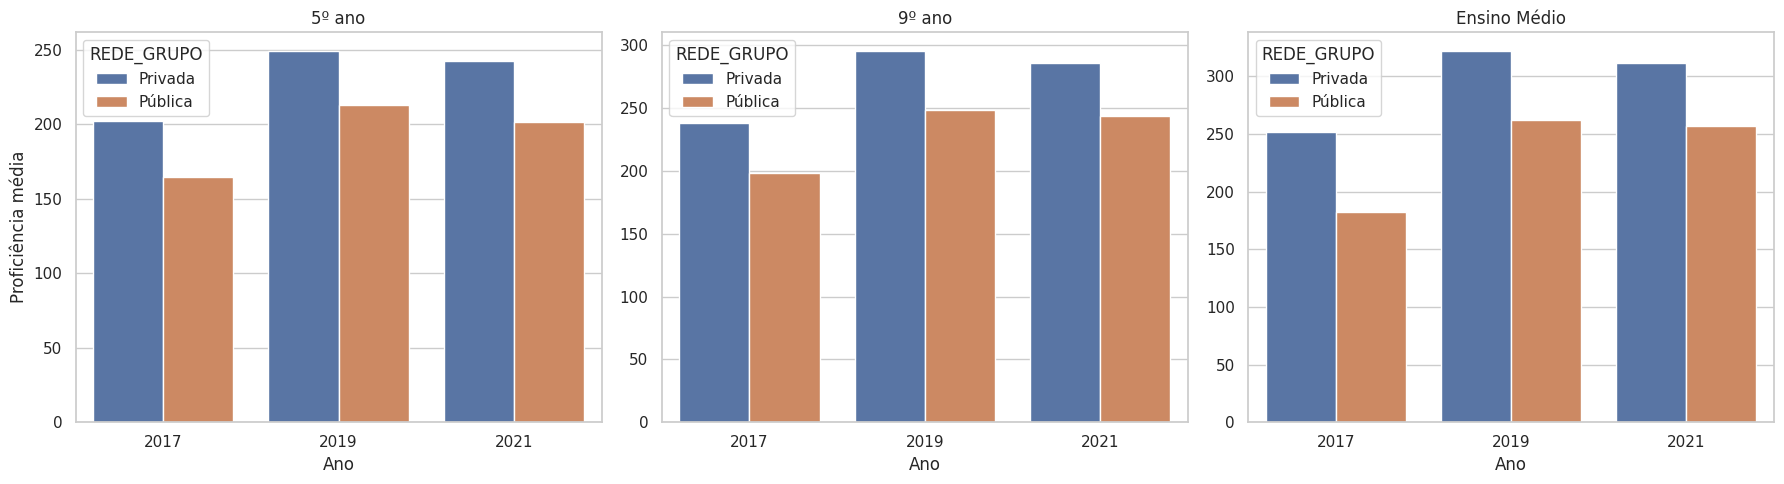

In [ ]:

plt.figure(figsize=(18, 5))

# 1. 5º ano
plt.subplot(1, 3, 1)
sns.barplot(
    data=medias_rede_ano,
    x="ANO",
    y="MEDIA_5_MT",
    hue="REDE_GRUPO"
)
plt.title("5º ano")
plt.ylabel("Proficiência média")
plt.xlabel("Ano")

# 2️. 9º ano
plt.subplot(1, 3, 2)
sns.barplot(
    data=medias_rede_ano,
    x="ANO",
    y="MEDIA_9_MT",
    hue="REDE_GRUPO"
)
plt.title("9º ano")
plt.ylabel("")
plt.xlabel("Ano")

# 3️. Ensino Médio
plt.subplot(1, 3, 3)
sns.barplot(
    data=medias_rede_ano,
    x="ANO",
    y="MEDIA_12_MT",
    hue="REDE_GRUPO"
)
plt.title("Ensino Médio")
plt.ylabel("")
plt.xlabel("Ano")

plt.tight_layout()
plt.show()



**Interpretação:**  
O gráfico evidencia diferença persistente entre rede pública e rede privada considerando três etapas educacionais (5º ano, 9º ano e Ensino Médio), permitindo identificar padrões consistentes de desempenho entre as redes pública e privada ao longo do tempo.. Em todos os anos analisados, a rede privada apresenta médias superiores, indicando que a desigualdade entre redes não é pontual, mas estrutural. Esse resultado sugere que fatores institucionais e contextuais associados à rede de ensino influenciam fortemente o desempenho em matemática.


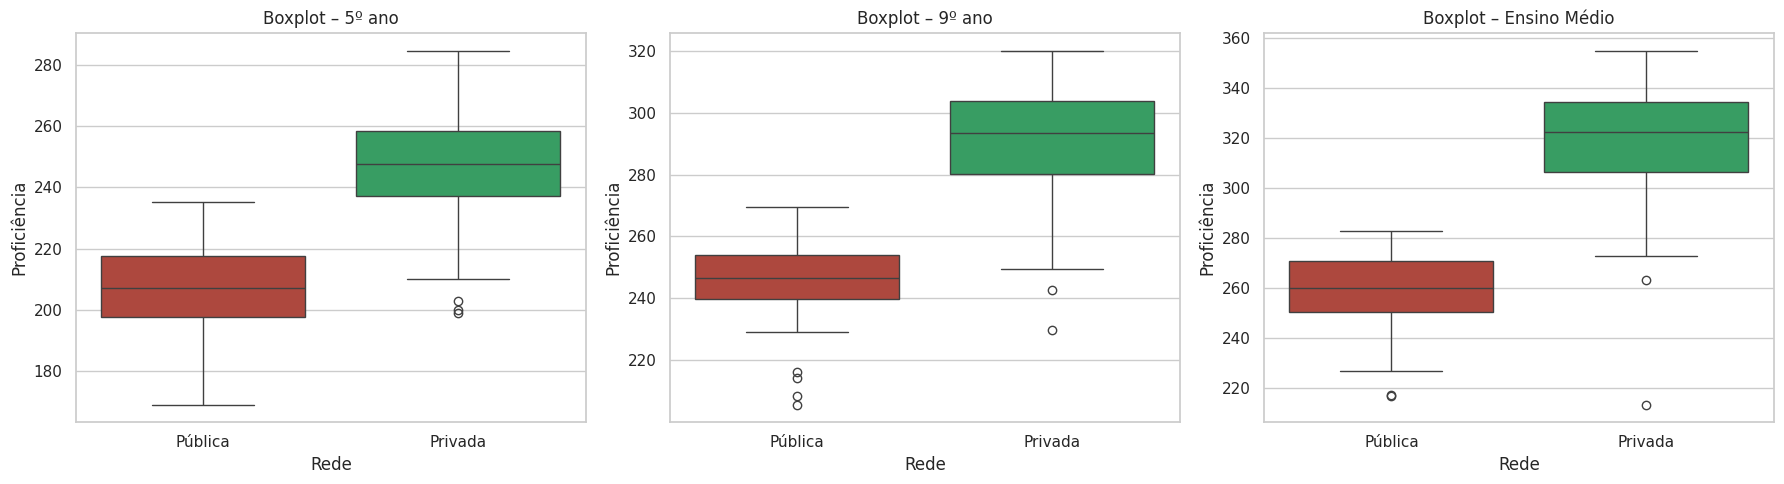

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharey=False)

etapas = [
    ("MEDIA_5_MT", "5º ano"),
    ("MEDIA_9_MT", "9º ano"),
    ("MEDIA_12_MT", "Ensino Médio")
]

for ax, (col, titulo) in zip(axes, etapas):

    df_temp = df_rede[
        (df_rede["ANO"].isin([2019, 2021])) &
        (df_rede["REDE_GRUPO"].isin(["Pública", "Privada"])) &
        (pd.to_numeric(df_rede[col], errors="coerce") > 0)
    ].copy()

    df_temp[col] = pd.to_numeric(df_temp[col], errors="coerce")

    sns.boxplot(
        data=df_temp,
        x="REDE_GRUPO",
        y=col,
        order=["Pública", "Privada"],
        palette={"Pública": "#C0392B", "Privada": "#27AE60"},
        ax=ax
    )

    ax.set_title(f"Boxplot – {titulo}")
    ax.set_xlabel("Rede")
    ax.set_ylabel("Proficiência")

plt.tight_layout()
plt.show()


**Interpretação:**  
Os boxplots mostram que a vantagem da rede privada não aparece apenas na média, mas também ao longo da distribuição dos resultados. Em geral, a mediana da rede privada é superior à da rede pública, e a distribuição da rede pública revela maior heterogeneidade, o que pode indicar desigualdade interna mais intensa entre estados.



## 12. Análise Exploratória — Urbano vs Rural

Agora será investigado a localização da escola, utilizando apenas os registros com dependência total para isolar esse efeito.


In [ ]:

# criar o recorte correto
df_localizacao = df_all[
    (df_all["DEPENDENCIA_ADM"] == "Total") &
    (df_all["LOCALIZACAO"].isin(["Urbana", "Rural"]))
].copy()

# garantir tipo numérico
cols = ["MEDIA_5_MT", "MEDIA_9_MT", "MEDIA_12_MT"]

for col in cols:
    df_localizacao[col] = pd.to_numeric(
        df_localizacao[col].astype(str).str.replace(",", "."),
        errors="coerce"
    )

# calcular médias
medias_localizacao = (
    df_localizacao
    .groupby(["ANO", "LOCALIZACAO"])[cols]
    .mean()
    .reset_index()
)

medias_localizacao


,ANO,LOCALIZACAO,MEDIA_5_MT,MEDIA_9_MT,MEDIA_12_MT
0,2017,Rural,171.274198,195.463457,188.883086
1,2017,Urbana,219.118148,254.450617,266.687284
2,2019,Rural,204.596250,242.780000,256.288750
3,2019,Urbana,224.786250,260.499375,274.983750
4,2021,Rural,194.505000,236.611250,250.503750
5,2021,Urbana,214.011875,254.465000,267.988750


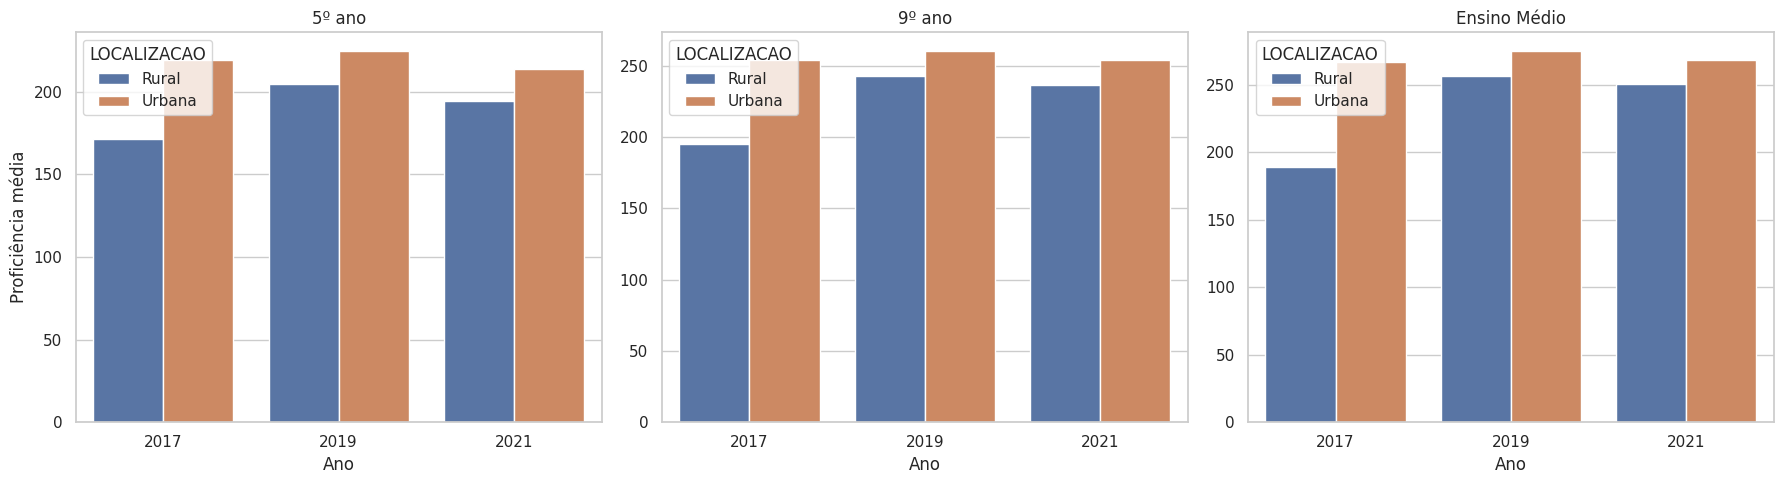

In [ ]:

plt.figure(figsize=(18, 5))

# 1️. 5º ano
plt.subplot(1, 3, 1)
sns.barplot(
    data=medias_localizacao,
    x="ANO",
    y="MEDIA_5_MT",
    hue="LOCALIZACAO"
)
plt.title("5º ano")
plt.ylabel("Proficiência média")
plt.xlabel("Ano")

# 2️. 9º ano
plt.subplot(1, 3, 2)
sns.barplot(
    data=medias_localizacao,
    x="ANO",
    y="MEDIA_9_MT",
    hue="LOCALIZACAO"
)
plt.title("9º ano")
plt.ylabel("")
plt.xlabel("Ano")

# 3️. Ensino Médio
plt.subplot(1, 3, 3)
sns.barplot(
    data=medias_localizacao,
    x="ANO",
    y="MEDIA_12_MT",
    hue="LOCALIZACAO"
)
plt.title("Ensino Médio")
plt.ylabel("")
plt.xlabel("Ano")

plt.tight_layout()
plt.show()



**Interpretação:**  
A análise por localização foi realizada considerando diferentes etapas de ensino (5º ano, 9º ano e Ensino Médio), permitindo verificar que o padrão de maior desempenho das escolas urbanas se mantém ao longo de toda a trajetória escolar. Essa diferença sugere a existência de desigualdades relacionadas à infraestrutura escolar, ao acesso a recursos e às oportunidades de aprendizagem, reforçando a importância da localização como fator relevante para compreender os resultados em matemática.


In [ ]:
   mapa_regiao = {
    "Rondônia": "Norte",
    "Acre": "Norte",
    "Amazonas": "Norte",
    "Roraima": "Norte",
    "Pará": "Norte",
    "Amapá": "Norte",
    "Tocantins": "Norte",
    "Maranhão": "Nordeste",
    "Piauí": "Nordeste",
    "Ceará": "Nordeste",
    "Rio Grande do Norte": "Nordeste",
    "Paraíba": "Nordeste",
    "Pernambuco": "Nordeste",
    "Alagoas": "Nordeste",
    "Sergipe": "Nordeste",
    "Bahia": "Nordeste",
    "Minas Gerais": "Sudeste",
    "Espírito Santo": "Sudeste",
    "Rio de Janeiro": "Sudeste",
    "São Paulo": "Sudeste",
    "Paraná": "Sul",
    "Santa Catarina": "Sul",
    "Rio Grande do Sul": "Sul",
    "Mato Grosso": "Centro-Oeste",
    "Mato Grosso do Sul": "Centro-Oeste",
    "Goiás": "Centro-Oeste",
    "Distrito Federal": "Centro-Oeste"
}

df_rede["REGIAO"] = df_rede["NO_UF"].map(mapa_regiao)
print("Coluna REGIAO criada com sucesso")

Coluna REGIAO criada com sucesso


In [ ]:
df_rede[["NO_UF", "REGIAO"]].head()

,NO_UF,REGIAO
0,Rondônia,Norte
1,Rondônia,Norte
2,Rondônia,Norte
3,Rondônia,Norte
4,Rondônia,Norte


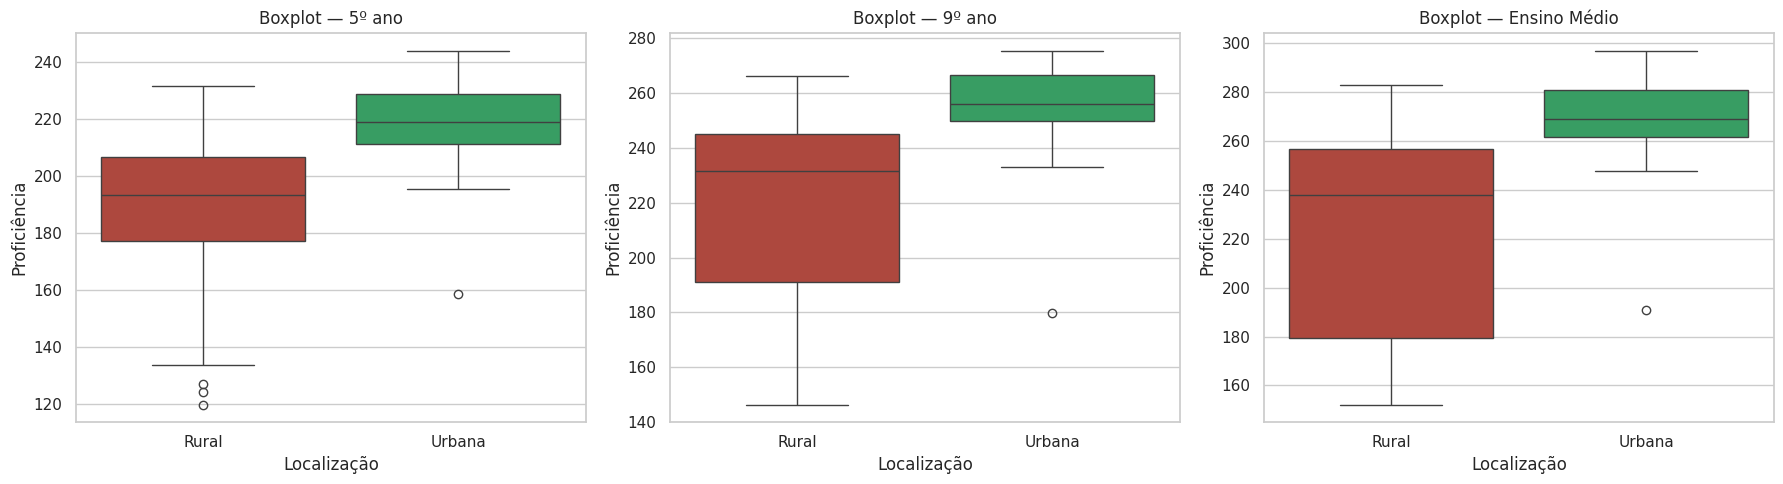

In [ ]:

fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharey=False)

for ax, (col, titulo) in zip(axes, etapas):
    sns.boxplot(
        data=df_localizacao,
        x="LOCALIZACAO",
        y=col,
        order=["Rural", "Urbana"],
        palette={"Rural": "#C0392B", "Urbana": "#27AE60"},
        ax=ax
    )
    ax.set_title(f"Boxplot — {titulo}")
    ax.set_xlabel("Localização")
    ax.set_ylabel("Proficiência")

plt.tight_layout()
plt.show()



**Interpretação:**  
Os boxplots confirmam que a diferença entre urbano e rural não se restringe a casos isolados. Em diferentes etapas, as distribuições urbanas tendem a ocupar níveis mais altos de proficiência, enquanto as distribuições rurais apresentam resultados mais baixos e, em alguns casos, maior sensibilidade à variação entre estados.



## 13. Análise Regional

A terceira dimensão do estudo considera a região do país. Aqui o foco é investigar se as desigualdades entre redes e localizações também se distribuem regionalmente.


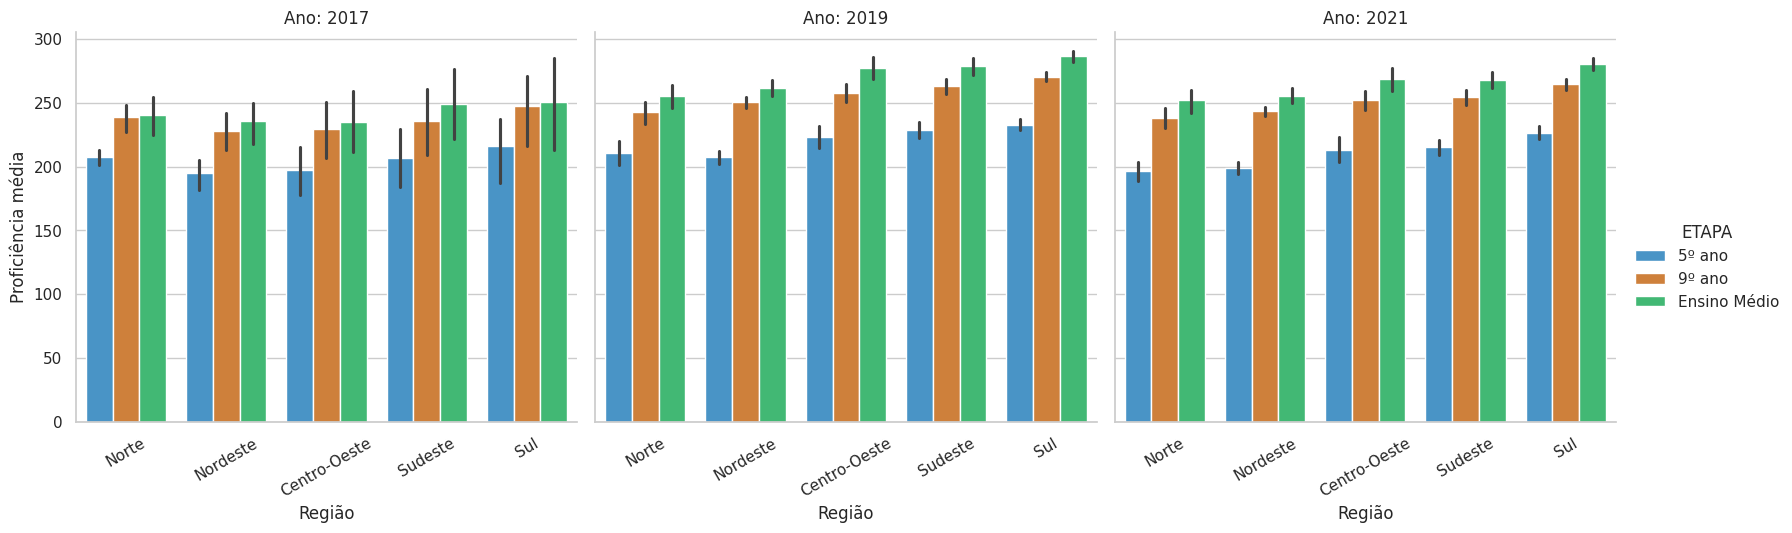

In [ ]:

# 13. Análise exploratória — Região

# 1️. filtrar dados: apenas linhas "Total"
df_regiao = df_all[
    df_all["DEPENDENCIA_ADM"] == "Total"
].copy()

# 2️. transformar para formato longo
df_long = df_regiao.melt(
    id_vars=["ANO", "REGIAO"],
    value_vars=["MEDIA_5_MT", "MEDIA_9_MT", "MEDIA_12_MT"],
    var_name="ETAPA",
    value_name="PROFICIENCIA"
)

# 3️. renomear etapas
mapa_etapas = {
    "MEDIA_5_MT": "5º ano",
    "MEDIA_9_MT": "9º ano",
    "MEDIA_12_MT": "Ensino Médio"
}

df_long["ETAPA"] = df_long["ETAPA"].map(mapa_etapas)

# 4️. ordem das regiões
ordem_regioes = ["Norte", "Nordeste", "Centro-Oeste", "Sudeste", "Sul"]

# 5️. gráfico separado por ano
g = sns.catplot(
    data=df_long,
    x="REGIAO",
    y="PROFICIENCIA",
    hue="ETAPA",
    col="ANO",
    kind="bar",
    order=ordem_regioes,
    height=5,
    aspect=1.1,
    palette={
        "5º ano": "#3498DB",
        "9º ano": "#E67E22",
        "Ensino Médio": "#2ECC71"
    }
)

# 6️. ajustes visuais
g.set_axis_labels("Região", "Proficiência média")
g.set_titles("Ano: {col_name}")

for ax in g.axes.flat:
    for label in ax.get_xticklabels():
        label.set_rotation(30)

plt.show()


**Interpretação:**  
A análise regional mostra que as médias de proficiência não se distribuem de forma uniforme pelo país. Regiões historicamente mais favorecidas tendem a apresentar resultados superiores, enquanto regiões com maiores vulnerabilidades acumulam médias mais baixas. Isso reforça a hipótese de que o desempenho em matemática também está ligado a fatores estruturais mais amplos.


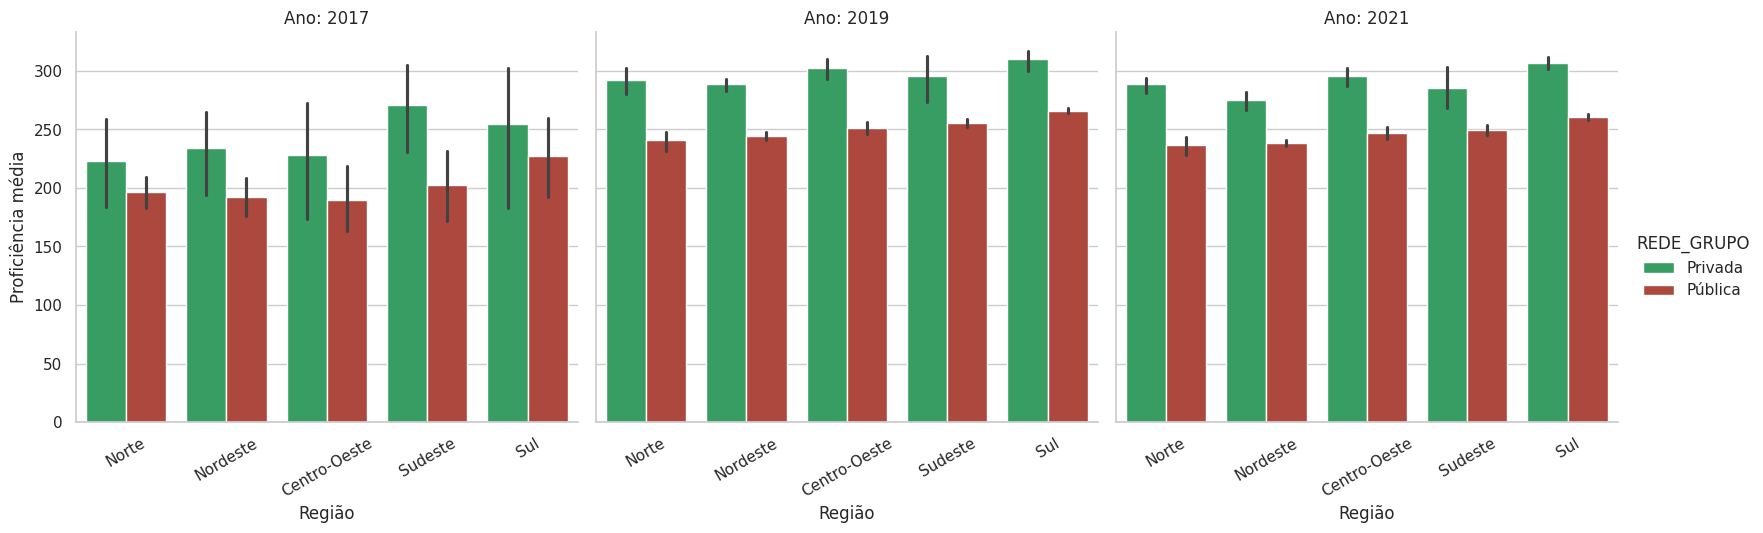

In [ ]:

g = sns.catplot(
    data=df_rede,
    x="REGIAO",
    y="MEDIA_9_MT",
    hue="REDE_GRUPO",
    col="ANO",
    kind="bar",
    order=ordem_regioes,
    height=5,
    aspect=1.1,
    palette={"Pública": "#C0392B", "Privada": "#27AE60"}
)

g.set_axis_labels("Região", "Proficiência média")
g.set_titles("Ano: {col_name}")

for ax in g.axes.flat:
    for label in ax.get_xticklabels():
        label.set_rotation(30)

plt.show()


**Interpretação:**  
Ao combinar região e rede de ensino, observa-se que a desigualdade entre público e privado permanece dentro das próprias regiões. Isso sugere que o efeito da rede de ensino não substitui a desigualdade regional; ao contrário, ambas as dimensões parecem coexistir e se sobrepor, ampliando o quadro de desigualdade educacional.


## 14. Visualização Espacial (Mapa do Brasil)

In [ ]:
!pip install geopandas geobr mapclassify -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 338.0/338.0 kB 15.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.0/5.0 MB 73.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.1/3.1 MB 70.1 MB/s eta 0:00:00


In [ ]:
import geopandas as gpd
import geobr
import matplotlib.pyplot as plt

In [ ]:
# corrigir nomes das UFs
df_mapa = df_all[
    (df_all["ANO"] == 2021) &
    (df_all["DEPENDENCIA_ADM"] == "Total")
].copy()

df_mapa["NO_UF"] = df_mapa["NO_UF"].replace({
    "RondÃ´nia": "Rondônia",
    "ParÃ¡": "Pará",
    "AmapÃ¡": "Amapá",
    "MaranhÃ£o": "Maranhão",
    "PiauÃ­": "Piauí",
    "CearÃ¡": "Ceará",
    "ParaÃ­ba": "Paraíba",
    "GoiÃ¡s": "Goiás",
    "EspÃ­rito Santo": "Espírito Santo",
    "SÃ£o Paulo": "São Paulo"
})

# siglas
uf_sigla = {
    "Rondônia": "RO", "Acre": "AC", "Amazonas": "AM", "Roraima": "RR",
    "Pará": "PA", "Amapá": "AP", "Tocantins": "TO",
    "Maranhão": "MA", "Piauí": "PI", "Ceará": "CE", "Rio Grande do Norte": "RN",
    "Paraíba": "PB", "Pernambuco": "PE", "Alagoas": "AL", "Sergipe": "SE", "Bahia": "BA",
    "Minas Gerais": "MG", "Espírito Santo": "ES", "Rio de Janeiro": "RJ", "São Paulo": "SP",
    "Paraná": "PR", "Santa Catarina": "SC", "Rio Grande do Sul": "RS",
    "Mato Grosso": "MT", "Mato Grosso do Sul": "MS", "Goiás": "GO", "Distrito Federal": "DF"
}

df_mapa["UF_SIGLA"] = df_mapa["NO_UF"].map(uf_sigla)

df_mapa = df_all[
    (df_all["ANO"] == 2021) &
    (df_all["DEPENDENCIA_ADM"] == "Total")
].copy()

df_mapa["NO_UF"] = df_mapa["NO_UF"].replace({
    "RondÃ´nia": "Rondônia",
    "ParÃ¡": "Pará",
    "AmapÃ¡": "Amapá",
    "MaranhÃ£o": "Maranhão",
    "PiauÃ­": "Piauí",
    "CearÃ¡": "Ceará",
    "ParaÃ­ba": "Paraíba",
    "GoiÃ¡s": "Goiás",
    "EspÃ­rito Santo": "Espírito Santo",
    "SÃ£o Paulo": "São Paulo"
})

df_mapa["UF_SIGLA"] = df_mapa["NO_UF"].map(uf_sigla)

df_mapa["MEDIA_12_MT"] = pd.to_numeric(df_mapa["MEDIA_12_MT"], errors="coerce")

df_mapa = df_mapa[df_mapa["UF_SIGLA"].notna()].copy()

df_mapa = df_mapa.groupby(["UF_SIGLA"], as_index=False)["MEDIA_12_MT"].mean()

df_mapa.head()










,UF_SIGLA,MEDIA_12_MT
0,AC,261.966667
1,AL,252.370000
2,AM,235.943333
3,BA,247.096667
4,DF,283.006667


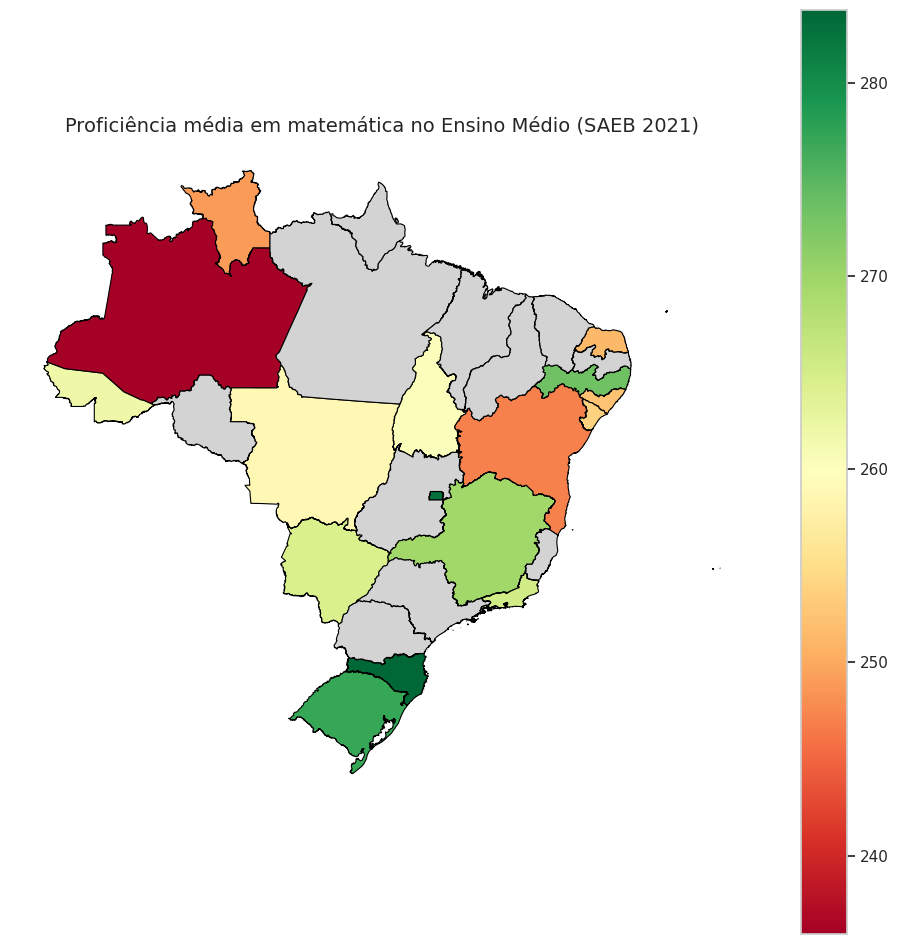

In [ ]:
# mapa das UFs do Brasil
brasil_uf = geobr.read_state(year=2020)

# juntar mapa com sua base
mapa_final = brasil_uf.merge(
    df_mapa,
    left_on="abbrev_state",
    right_on="UF_SIGLA",
    how="left"
)

# plotar mapa
fig, ax = plt.subplots(1, 1, figsize=(12, 12))

mapa_final.plot(
    column="MEDIA_12_MT",
    cmap="RdYlGn",
    linewidth=0.8,
    edgecolor="black",
    legend=True,
    ax=ax,
    missing_kwds={"color": "lightgrey", "label": "Sem dados"}
)

ax.set_title("Proficiência média em matemática no Ensino Médio (SAEB 2021)", fontsize=14)
ax.axis("off")

plt.show()

**Interpretação:**

A escala de cores utilizada no mapa segue o padrão RdYlGn (Red–Yellow–Green), no qual:

Tons em vermelho representam menores níveis de proficiência em matemática;
Tons intermediários (amarelo) indicam desempenho médio;
Tons em verde representam maiores níveis de proficiência.
Os estados representados em cinza correspondem àqueles que não apresentaram dados válidos na base filtrada (dependência administrativa total) para o ano de 2021.

Assim, quanto mais próximo do verde, melhor o desempenho educacional observado, enquanto tons mais avermelhados indicam maiores dificuldades de aprendizagem.
O mapa evidencia a distribuição espacial da proficiência média em matemática no Ensino Médio no Brasil. Observa-se que estados das regiões Sul e Sudeste tendem a apresentar níveis mais elevados de proficiência, enquanto parte dos estados das regiões Norte e Nordeste apresenta valores relativamente menores.
Essa visualização reforça os achados da análise regional anterior, indicando que o desempenho em matemática também possui uma dimensão territorial. Assim, o mapa contribui para evidenciar que as desigualdades educacionais no Brasil não são apenas institucionais, mas também espaciais.


## 15. Histogramas

Os histogramas ajudam a visualizar a distribuição das proficiências e identificar concentração, dispersão e possíveis assimetrias.


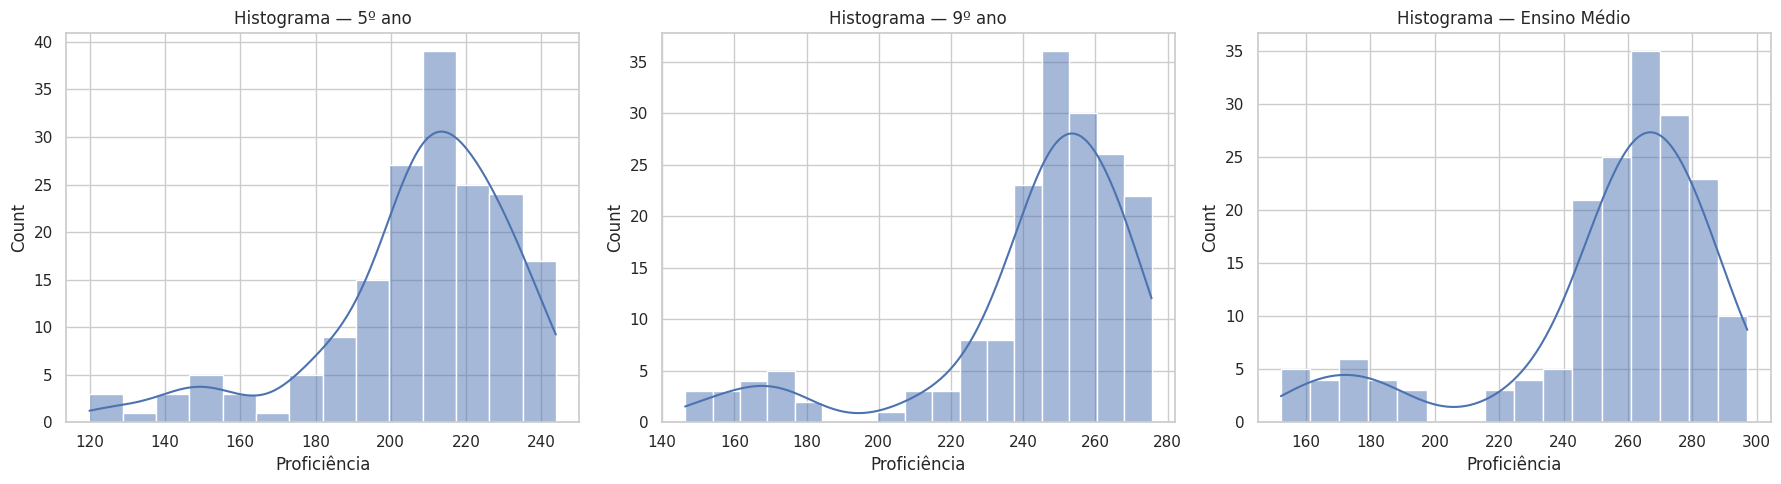

In [ ]:

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, (col, titulo) in zip(axes, etapas):
    sns.histplot(
        data=df_all[df_all["DEPENDENCIA_ADM"] == "Total"],
        x=col,
        kde=True,
        ax=ax
    )
    ax.set_title(f"Histograma — {titulo}")
    ax.set_xlabel("Proficiência")

plt.tight_layout()
plt.show()



**Interpretação:**  
Os histogramas indicam que as distribuições das proficiências apresentam formato aproximadamente normal, com maior concentração de valores em torno da média. Observa-se um deslocamento progressivo das distribuições para a direita do 5º ano ao Ensino Médio, evidenciando aumento das proficiências médias. Entretanto, também se verifica um aumento da dispersão nas etapas mais avançadas, indicando maior heterogeneidade no desempenho dos estudantes, especialmente no Ensino Médio, o que pode refletir desigualdades acumuladas ao longo da trajetória escolar.



## 16. Matriz de Correlação

A matriz de correlação permite observar se estados que vão bem em uma etapa tendem também a apresentar bom desempenho nas demais etapas.


In [ ]:

corr = df_all[df_all["DEPENDENCIA_ADM"] == "Total"][["MEDIA_5_MT", "MEDIA_9_MT", "MEDIA_12_MT"]].corr()

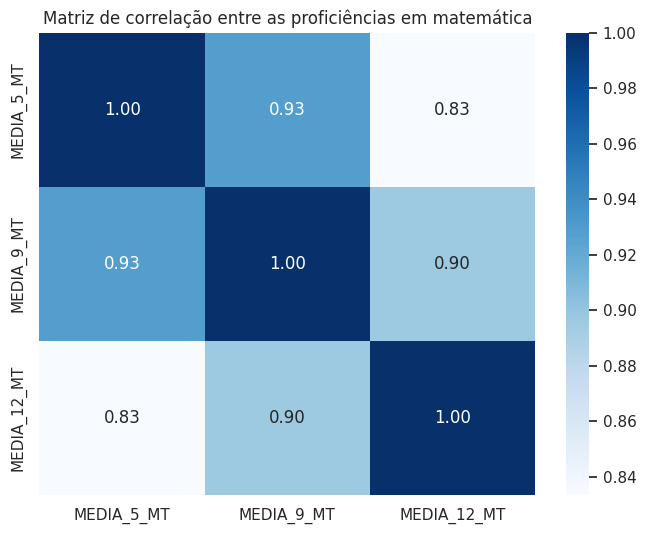

In [ ]:

plt.figure(figsize=(8, 6))
sns.heatmap(corr, annot=True, cmap="Blues", fmt=".2f")
plt.title("Matriz de correlação entre as proficiências em matemática")
plt.show()



**Interpretação:**  
A matriz de correlação evidencia uma forte relação positiva entre as proficiências das diferentes etapas de ensino. Destaca-se a elevada correlação entre o 5º e o 9º ano (0,93), indicando forte continuidade no desempenho ao longo do ensino fundamental. As correlações entre o 9º ano e o Ensino Médio (0,90), bem como entre o 5º ano e o Ensino Médio (0,83), também são elevadas, sugerindo que estados com melhor desempenho inicial tendem a manter níveis mais altos de proficiência ao longo da trajetória escolar. Esses resultados indicam persistência do desempenho educacional e possíveis desigualdades estruturais entre as unidades federativas.


## 17. Pré-processamento adicional

Além da padronização inicial dos arquivos, esta etapa inclui:
- tratamento de valores faltantes;
- criação de variáveis derivadas;
- construção de versões normalizadas e padronizadas da base.

Essas operações são úteis para organizar melhor os dados e prepará-los para análises futuras.


In [ ]:

df_proc = df_rede.copy()

# Tratamento simples de ausentes nas métricas principais:
for col in ["MEDIA_5_MT", "MEDIA_9_MT", "MEDIA_12_MT"]:
    df_proc[col] = df_proc.groupby(["ANO", "DEPENDENCIA_ADM"])[col].transform(
        lambda s: s.fillna(s.median())
    )

# Criação de métricas derivadas:
df_proc["GAP_9_5"] = df_proc["MEDIA_9_MT"] - df_proc["MEDIA_5_MT"]
df_proc["GAP_12_9"] = df_proc["MEDIA_12_MT"] - df_proc["MEDIA_9_MT"]
df_proc["VAR_REL_9_5"] = df_proc["GAP_9_5"] / df_proc["MEDIA_5_MT"]
df_proc["VAR_REL_12_9"] = df_proc["GAP_12_9"] / df_proc["MEDIA_9_MT"]

df_proc.head()


,ANO,CO_UF,NO_UF,REGIAO,DEPENDENCIA_ADM,LOCALIZACAO,MEDIA_5_MT,MEDIA_9_MT,MEDIA_12_MT,REDE_GRUPO,GAP_9_5,GAP_12_9,VAR_REL_9_5,VAR_REL_12_9
0,2017,11.0,Rondônia,Norte,Privada,Rural,151.433333,178.640000,188.940000,Privada,27.206667,10.300000,0.179661,0.057658
1,2017,11.0,Rondônia,Norte,Privada,Total,252.763333,302.640000,317.580000,Privada,49.876667,14.940000,0.197326,0.049366
2,2017,11.0,Rondônia,Norte,Privada,Urbana,252.930000,304.620000,319.136667,Privada,51.690000,14.516667,0.204365,0.047655
3,2017,11.0,Rondônia,Norte,Pública,Rural,169.460000,202.354667,153.720000,Pública,32.894667,-48.634667,0.194115,-0.240344
4,2017,11.0,Rondônia,Norte,Pública,Total,175.648000,204.155333,160.744000,Pública,28.507333,-43.411333,0.162298,-0.212639



**Interpretação:**  
O tratamento de ausentes por mediana dentro de grupos evita perda desnecessária de registros e reduz o impacto de valores extremos. Já as variáveis derivadas ajudam a descrever a variação do desempenho entre etapas, permitindo observar se a trajetória média cresce, diminui ou se mantém relativamente estável.


In [ ]:

colunas_numericas = ["MEDIA_5_MT", "MEDIA_9_MT", "MEDIA_12_MT", "GAP_9_5", "GAP_12_9"]

scaler_std = StandardScaler()
scaler_mm = MinMaxScaler()

df_std = df_proc.copy()
df_mm = df_proc.copy()

df_std[[f"{c}_z" for c in colunas_numericas]] = scaler_std.fit_transform(df_proc[colunas_numericas])
df_mm[[f"{c}_mm" for c in colunas_numericas]] = scaler_mm.fit_transform(df_proc[colunas_numericas])

df_std.head(3)


,ANO,CO_UF,NO_UF,REGIAO,DEPENDENCIA_ADM,LOCALIZACAO,MEDIA_5_MT,MEDIA_9_MT,MEDIA_12_MT,REDE_GRUPO,GAP_9_5,GAP_12_9,VAR_REL_9_5,VAR_REL_12_9,MEDIA_5_MT_z,MEDIA_9_MT_z,MEDIA_12_MT_z,GAP_9_5_z,GAP_12_9_z
0,2017,11.0,Rondônia,Norte,Privada,Rural,151.433333,178.64,188.940000,Privada,27.206667,10.300000,0.179661,0.057658,-1.082528,-1.117612,-0.867940,-0.370132,0.005165
1,2017,11.0,Rondônia,Norte,Privada,Total,252.763333,302.64,317.580000,Privada,49.876667,14.940000,0.197326,0.049366,0.901619,0.960746,0.810783,0.366233,0.146507
2,2017,11.0,Rondônia,Norte,Privada,Urbana,252.930000,304.62,319.136667,Privada,51.690000,14.516667,0.204365,0.047655,0.904883,0.993933,0.831098,0.425133,0.133612



**Interpretação:**  
A criação de versões padronizadas e normalizadas da base atende ao requisito de pré-processamento e amplia a utilidade analítica do conjunto de dados. Ainda que a análise central deste MVP seja descritiva, manter visões transformadas do dataset facilita comparações futuras e eventuais extensões do estudo.



## 18. Reanálise após pré-processamento

A seguir, observamos a distribuição da variável derivada `GAP_9_5` e `GAP_12_9`, que representam as diferenças entre a proficiência do 9º e do 5º ano, bem como do Ensino Médio e a do 9º ano.


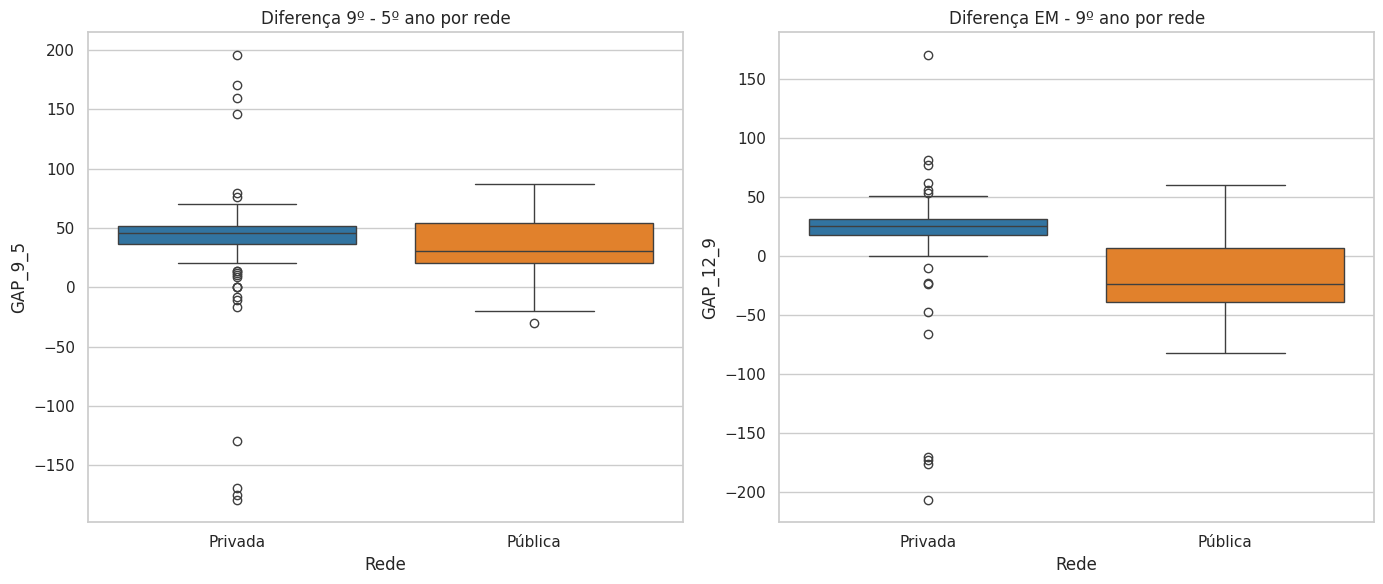

In [ ]:

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# paleta de cores
cores = {"Privada": "#1f77b4", "Pública": "#ff7f0e"}

# GAP 9 - 5
sns.boxplot(
    data=df_proc[df_proc["DEPENDENCIA_ADM"].isin(["Pública", "Privada"])],
    x="REDE_GRUPO",
    y="GAP_9_5",
    palette=cores,
    ax=axes[0]
)

axes[0].set_title("Diferença 9º - 5º ano por rede")
axes[0].set_xlabel("Rede")
axes[0].set_ylabel("GAP_9_5")

# GAP 12 - 9
sns.boxplot(
    data=df_proc[df_proc["DEPENDENCIA_ADM"].isin(["Pública", "Privada"])],
    x="REDE_GRUPO",
    y="GAP_12_9",
    palette=cores,
    ax=axes[1]
)

axes[1].set_title("Diferença EM - 9º ano por rede")
axes[1].set_xlabel("Rede")
axes[1].set_ylabel("GAP_12_9")

plt.tight_layout()
plt.show()



**Interpretação:**  
A análise comparativa dos boxplots evidencia que tanto a rede pública quanto a privada apresentam crescimento da proficiência entre o 5º e o 9º ano, embora a rede privada apresente maior consistência e níveis mais elevados. No entanto, ao observar a transição do 9º ano para o Ensino Médio, verifica-se um comportamento distinto: enquanto a rede privada mantém a evolução do desempenho, a rede pública apresenta queda significativa na proficiência média, além de maior dispersão dos resultados. Esses achados indicam que os principais desafios educacionais concentram-se na etapa do Ensino Médio, especialmente na rede pública, sugerindo a necessidade de intervenções específicas nesse nível de ensino.



## 19. Síntese das hipóteses

Com base nas análises exploratórias realizadas, é possível discutir as hipóteses iniciais:

- **Hipótese 1 (Privada > Pública):** Confirmada com forte evidência. Encontra respaldo nos dados, já que a rede privada apresenta médias superiores à rede pública.
    - Aparece em praticamente todas as análises;
    - Boxplots, mapas e médias mostram padrão consistente;

- **Hipótese 2 (Urbano > Rural):** Confirmada. Também encontra suporte, uma vez que os contextos urbanos tendem a superar os rurais.
    - Diferença recorrente nos dados;
    - Indica influência de infraestrutura e acesso;

- **Hipótese 3 (Desigualdade Regional):** é reforçada pelos resultados regionais, que mostram distribuição desigual da proficiência entre regiões.
    - Mapa evidenciou concentração de melhores resultados em algumas regiões;
    - Norte e Nordeste com maiores desafios;

- **Hipótese 4 (Persistência ao Longo dos Anos):** Confirmada. Encontra evidências ao longo dos anos, indicando persistência das desigualdades.
    - Padrões se repetem entre 2017, 2019 e 2021;
    - Indica problema estrutural, não pontual;

- **Hipótese 5 (Fatores Estruturais):** Não testada diretamente. Permanece como hipótese interpretativa plausível, mas não pode ser testada diretamente com esta base específica.
    - Dados não possuem variável específica;
    - Permanece como hipótese interpretativa coerente;





## 20. Conclusão

Cabe destacar que a escolha dos anos de 2017, 2019 e 2021 se deu por representarem os ciclos mais recentes com dados consolidados do SAEB disponíveis no momento da análise. Além disso, o ano de 2021 está inserido no contexto da pandemia de COVID-19, o que pode ter impactado significativamente o desempenho dos estudantes, seja pela interrupção das aulas presenciais, seja pelas dificuldades de acesso ao ensino remoto. Dessa forma, a inclusão desse período permite não apenas a análise de tendências, mas também a consideração de possíveis efeitos atípicos no desempenho educacional. Ressalta-se ainda que, até o momento da realização deste estudo, não havia disponibilidade de dados consolidados para anos posteriores, o que justifica o recorte temporal adotado.

Adicionalmente, destaca-se que o interesse por esta investigação está diretamente relacionado à minha atuação profissional como professor de matemática, o que motivou a busca por compreender, a partir de dados concretos, os fatores associados ao desempenho dos estudantes nessa área do conhecimento, contribuindo para uma análise mais contextualizada e relevante do cenário educacional brasileiro.

Os resultados deste estudo evidenciam que o desempenho em matemática no Brasil está fortemente associado a desigualdades estruturais, manifestadas entre redes de ensino, regiões e contextos territoriais. As análises indicam que, embora haja progressão no Ensino Fundamental em ambas as redes, a rede pública apresenta uma queda significativa na transição para o Ensino Médio, destacando esse nível como ponto crítico do sistema educacional.

Os padrões observados são consistentes ao longo dos anos analisados, sugerindo que tais desigualdades não são conjunturais, mas estruturais. Do ponto de vista metodológico, o trabalho cumpriu as etapas essenciais de um pipeline de análise de dados, incluindo pré-processamento, construção de métricas derivadas e exploração visual.

Como limitação, destaca-se a ausência de variáveis diretamente relacionadas à qualidade da oferta educacional, como formação docente. Ainda assim, os resultados sustentam a hipótese de que fatores estruturais desempenham papel central nas desigualdades observadas. Estudos futuros podem aprofundar essa análise com a integração de novas bases de dados e aplicação de modelos preditivos.

Como continuidade do estudo, recomenda-se a incorporação de bases complementares que permitam medir explicitamente a formação docente, possibilitando análises mais aprofundadas sobre seu impacto no desempenho em matemática.